## 2. Exercise

All three types of kernels appear to perform quite well on the digits data! Nonetheless, their performance can be improved!
1. Try to split your training data (again using **train_test_split**) to obtain a validation set. Try to optimize the performance of your model on the validation data, by trying different kernels (linear, poly, and rbf), different values of C, different decision function (ovr or ovo), and perhaps even other stuff. You can find a full list of options to tune at [https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html].

The main difference between this exercise and the one before is the number of parameters that actually our training and testing data have. Before they were just two features: a column about real numbers and labels. Right now we have 64 different features describing each observation of our data-set.

In [94]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [95]:
X, y = load_digits(return_X_y = True)
print("Shape of the data", X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Shape of the training and testing data", X_train.shape, X_test.shape)

Shape of the data (1797, 64) (1797,)
Shape of the training and testing data (1437, 64) (360, 64)


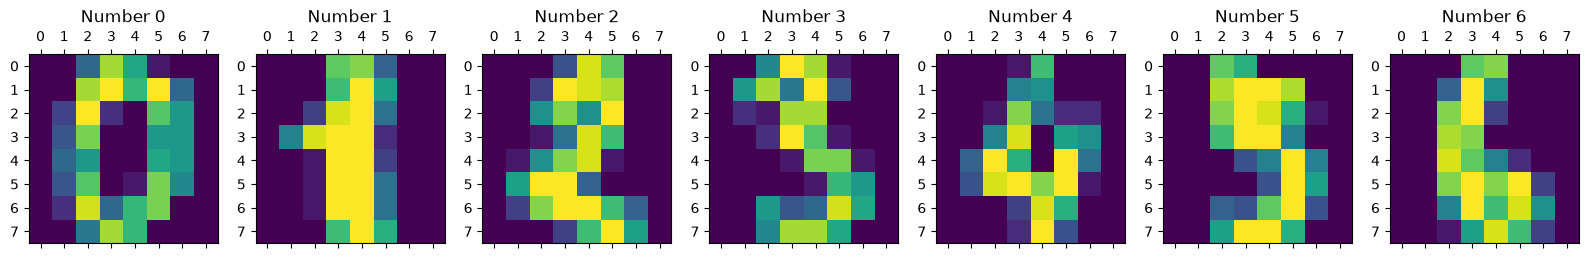

In [96]:
digits = load_digits()

fig = plt.figure(figsize = (20, 15))
for i in range(len(digits)):
    ax = fig.add_subplot(1, len(digits), i + 1)
    ax.matshow(digits.images[i])
    ax.set_title(f"Number {digits.target[i]}")
plt.show()

#### Predicting by a Linear SVM

In [97]:
svm_linear = svm.SVC(kernel = "linear")
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

In [98]:
accuracy_linear = accuracy_score(y_true = y_test, y_pred = y_pred_linear)

print(f"Accuracy of Linear model {round(accuracy_linear * 100, 1)}")

Accuracy of Linear model 97.8


#### Predicting by a Radial SVM OVR and OVO

In [99]:
svm_radial_ovr = svm.SVC(kernel = "rbf", decision_function_shape = "ovr")
svm_radial_ovo = svm.SVC(kernel = "rbf", decision_function_shape = "ovo")

svm_radial_ovr.fit(X_train, y_train)
svm_radial_ovo.fit(X_train, y_train)

y_pred_radial_ovr = svm_radial_ovr.predict(X_test) 
y_pred_radial_ovo = svm_radial_ovo.predict(X_test)

In [100]:
accuracy_radial_ovr = accuracy_score(y_true = y_test, y_pred = y_pred_radial_ovr)
accuracy_radial_ovo = accuracy_score(y_true = y_test, y_pred = y_pred_radial_ovo)

print(f"Accuracy of Radial model OVR {round(accuracy_radial_ovr * 100, 1)}")
print(f"Accuracy of Radial model OVO {round(accuracy_radial_ovo * 100, 1)}")

Accuracy of Radial model OVR 98.6
Accuracy of Radial model OVO 98.6


#### What does it actually fail?

Searching for how many wrong predictions our models have done.

Plotting Radial SVM with OVR (One-versus-rest)


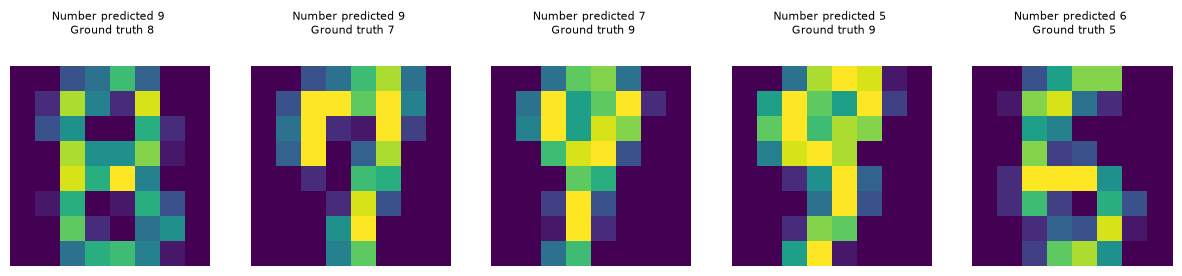

Plotting Radial SVM with OVO (One-versus-one)


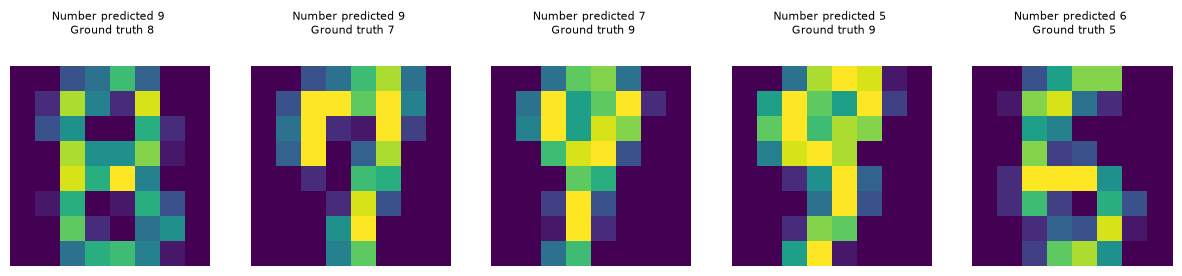

In [101]:
wrong_radial_ovr = np.where(y_pred_radial_ovr != y_test)[0]
wrong_radial_ovo = np.where(y_pred_radial_ovo != y_test)[0]

# We need to reshape the image since until now it has been used like a unique sequence of numbers (so a vector)

print("Plotting Radial SVM with OVR (One-versus-rest)")
fig = plt.figure(figsize = (15, 8))
for i, idx in enumerate(wrong_radial_ovr[:]):
    ax = fig.add_subplot(1, len(wrong_radial_ovr), i + 1)
    ax.set_title(f"Number predicted {y_pred_radial_ovr[idx]} \n Ground truth {y_test[idx]}", fontsize = 8)
    ax.matshow(X_test[idx].reshape(8, 8))
    ax.set_axis_off()
plt.show()

print("Plotting Radial SVM with OVO (One-versus-one)")
fig = plt.figure(figsize = (15, 8))
for i, idx in enumerate(wrong_radial_ovo[:]):
    ax = fig.add_subplot(1, len(wrong_radial_ovo), i + 1)
    ax.set_title(f"Number predicted {y_pred_radial_ovo[idx]} \n Ground truth {y_test[idx]}", fontsize = 8)
    ax.matshow(X_test[idx].reshape(8, 8))
    ax.set_axis_off()
plt.show()

In [102]:
print(f"Both of them have done a total number of {len(wrong_radial_ovr)} wrong predictions")

Both of them have done a total number of 5 wrong predictions
